In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

GLOBAL_SEED = 42

K          = 5      # number of experts
T          = 2000   # number of rounds
N_REPS     = 100    # repetitions for averaging
SWAP_EVERY = 200    # rounds between best-expert swaps (adversarial scenario)

plt.rcParams.update({
    'figure.dpi'     : 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
})
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

print("Setup complete.")

Setup complete.


## 2. Loss generators

Each generator returns a `(T, K)` array of losses in `[0, 1]`, with `seed` for reproducibility.

| Scenario | Expert 0 | Experts 1…K-1 | Regime |
|----------|----------|----------------|--------|
| Stochastic | Bernoulli(0.3) | Bernoulli(0.5) | Easy — AdaHedge should flatline |
| Adversarial | best expert rotates every `swap_every` rounds | — | Hard — all algorithms grow |
| Low-gap | Bernoulli(0.49) | Bernoulli(0.5) | Hard — gap is tiny, slow convergence |

In [ ]:
def generate_stochastic(K: int, T, seed):
    rng = np.random.default_rng(seed)
    losses = rng.binomial(1, 0.5, size=(T, K)).astype(float)
    losses[:, 0] = rng.binomial(1, 0.3, size=T)
    return losses


def generate_adversarial(
    K, T, seed, swap_every = SWAP_EVERY
):
    rng = np.random.default_rng(seed)
    losses = rng.binomial(1, 0.5, size=(T, K)).astype(float)
    for t in range(T):
        best = (t // swap_every) % K
        losses[t, best] = rng.binomial(1, 0.1)
    return losses


def generate_low_gap(K, T, seed):
    rng = np.random.default_rng(seed)
    losses = rng.binomial(1, 0.5, size=(T, K)).astype(float)
    losses[:, 0] = rng.binomial(1, 0.49, size=T)
    return losses

In [ ]:
def hedge(losses, eta):
  T, K = losses.shape
  weights     = np.ones(K) / K
  cum_loss    = 0.0
  expert_loss = np.zeros(K)

  cum_losses_t = np.empty(T)
  regret_t     = np.empty(T)

  for t in range(T):
    # Choose allocation
    p_t = weights / weights.sum()

    # Receive loss vector
    l_t = losses[t]

    # Suffer loss
    learner_loss = p_t @ l_t
    cum_loss    += learner_loss

    # update expert cumulative losses
    expert_loss += l_t

    # multiplicative weight update
    weights *= np.exp(-eta * l_t)

    cum_losses_t[t] = cum_loss
    regret_t[t]     = cum_loss - expert_loss.min()

  return {
      'cumulative_loss'  : cum_losses_t,
      'regret'           : regret_t,
  }

In [ ]:
def run_experiment_hedge(generator, eta_values, K=K, T=T, n_reps=N_REPS, **gen_kwargs):
    results = {}
    for eta in eta_values:
        regret_runs   = []
        cum_loss_runs = []
        for rep in range(n_reps):
            losses = generator(K, T, seed=rep, **gen_kwargs)
            res    = hedge(losses, eta)
            regret_runs.append(res['regret'])
            cum_loss_runs.append(res['cumulative_loss'])
        r = np.array(regret_runs)    # (n_reps, T)
        c = np.array(cum_loss_runs)  # (n_reps, T)
        results[f"Hedge η={eta}"] = {
            'regret_mean'   : r.mean(axis=0),
            'regret_std'    : r.std(axis=0),
            'cum_loss_mean' : c.mean(axis=0),
            'cum_loss_std'  : c.std(axis=0),
        }
    return results

ETA_VALUES = [0.01, 0.1, 0.5]

In [ ]:
results_stochastic  = run_experiment_hedge(generate_stochastic,  ETA_VALUES)
results_adversarial = run_experiment_hedge(generate_adversarial, ETA_VALUES, swap_every=SWAP_EVERY)
results_low_gap     = run_experiment_hedge(generate_low_gap,     ETA_VALUES)

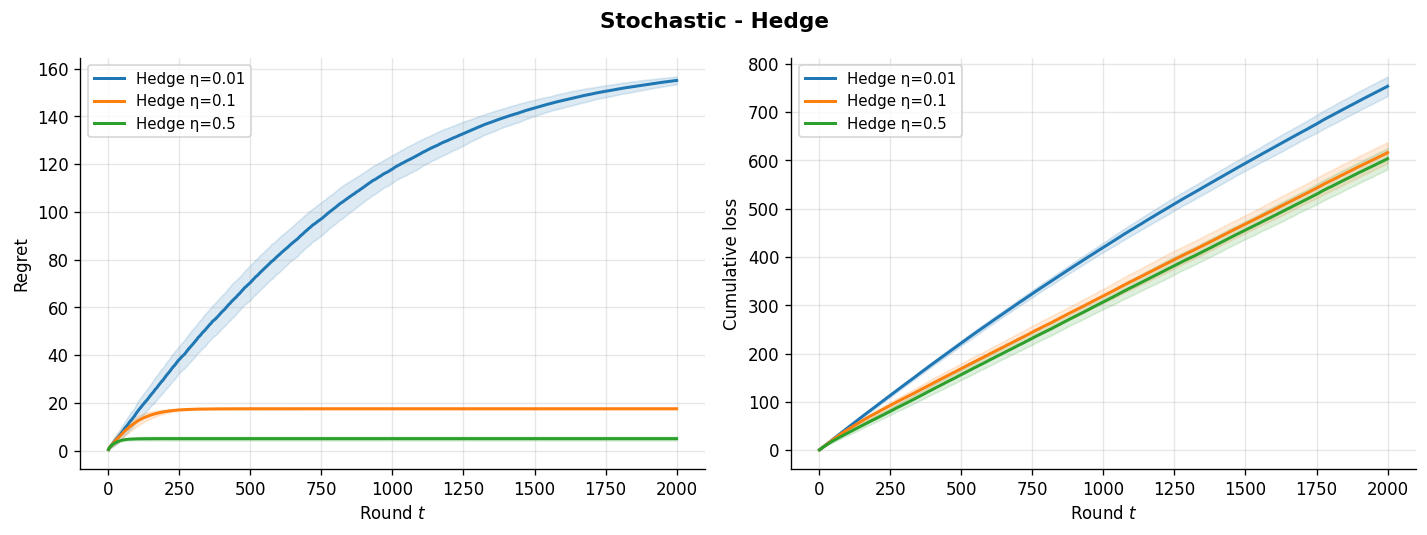

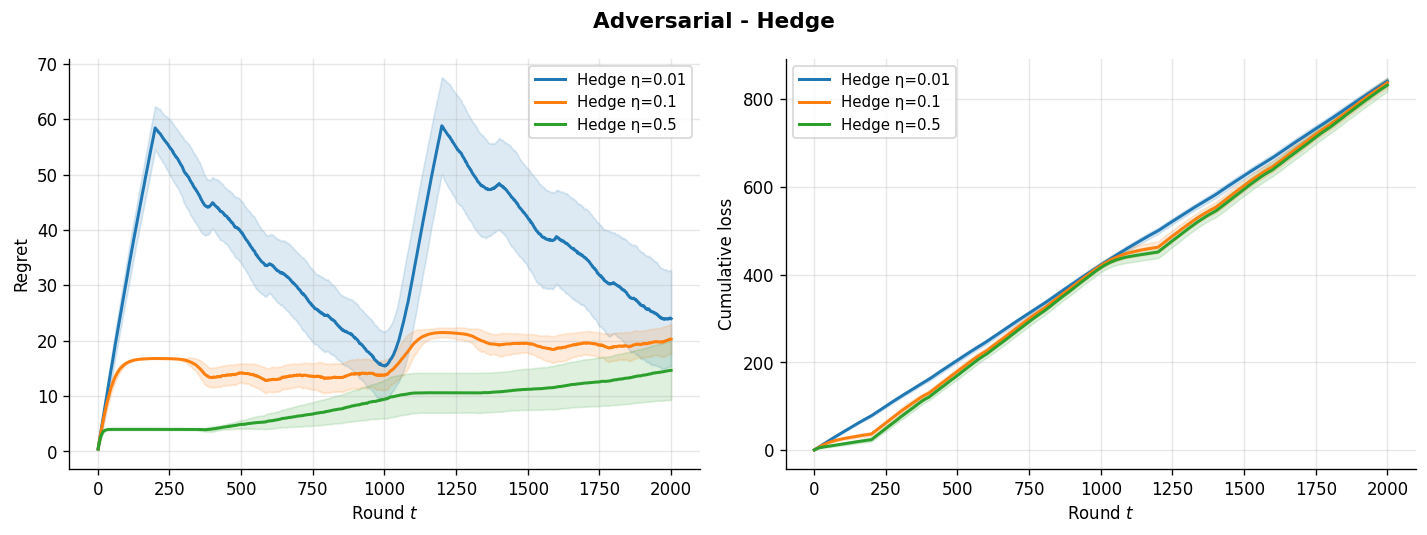

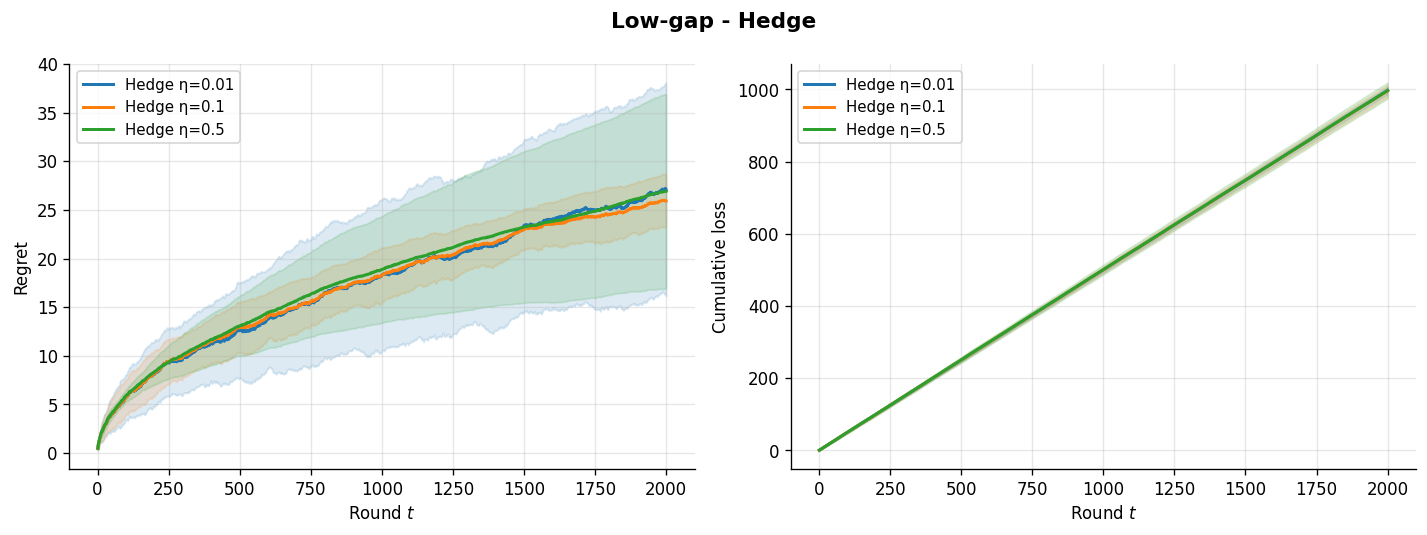

In [ ]:
def plot_scenario(results, title, T=T):
    t = np.arange(1, T + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, metric, ylabel in zip(
        axes,
        ['regret', 'cum_loss'],
        ['Regret', 'Cumulative loss'],
    ):
        for i, (name, data) in enumerate(results.items()):
            mean = data[f'{metric}_mean']
            std  = data[f'{metric}_std']
            ax.plot(t, mean, label=name, lw=1.8, color=COLORS[i])
            ax.fill_between(t, mean - std, mean + std, alpha=0.15, color=COLORS[i])
        ax.set_xlabel('Round $t$')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_scenario(results_stochastic,  "Stochastic - Hedge")
plot_scenario(results_adversarial, "Adversarial - Hedge")
plot_scenario(results_low_gap,     "Low-gap - Hedge")